# 4. Redes Neuronales de Capa Densa (MLP)

En este notebook aprenderás a construir y entrenar redes neuronales multicapa (MLP) para clasificación, usando scikit-learn y TensorFlow/Keras. Se incluye teoría, código, visualizaciones, análisis de hiperparámetros y recomendaciones prácticas.

## Objetivo
- Comprender la teoría y arquitectura de las redes neuronales densas (MLP).
- Implementar y comparar modelos MLP con scikit-learn y TensorFlow/Keras.
- Analizar el impacto de los hiperparámetros y visualizar el aprendizaje.
- Aplicar buenas prácticas para entrenamiento en CPU y GPU.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado los notebooks [01](./01_intro_machine_learning.ipynb), [02](./02_preprocesamiento_visualizacion.ipynb) y [03](./03_modelos_clasicos_ml.ipynb).

- Conceptos de clasificación, métricas y preprocesamiento.
- Familiaridad con scikit-learn.

## 1. Introducción teórica

Una red neuronal multicapa (MLP) es un modelo de aprendizaje profundo compuesto por capas densas (fully connected), donde cada neurona de una capa está conectada a todas las neuronas de la siguiente.

- **Capa de entrada:** Recibe los datos.
- **Capas ocultas:** Realizan transformaciones no lineales (activaciones).
- **Capa de salida:** Entrega la predicción.

**Ventajas:**
- Capacidad de modelar relaciones complejas.
- Flexibilidad en arquitectura y funciones de activación.

**Desventajas:**
- Requiere más datos y cómputo que modelos clásicos.
- Puede sobreajustar si no se regula bien.

## 2. Importación de librerías

In [14]:
# === Reproducibilidad ===
import random
import numpy as np
import os
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neural_network import MLPClassifier

# === Suprimir logs de TensorFlow/XLA ANTES de importar TF ===
# Con '3' se eliminan INFO/WARNING/ERROR del compilador XLA (dot_merger.cc, etc.)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.datasets import mnist

# Segunda capa: suprimir logs a nivel Python
import logging
tf.get_logger().setLevel(logging.ERROR)
logging.getLogger('tensorflow').setLevel(logging.ERROR)

tf.random.set_seed(SEED)

import warnings
warnings.filterwarnings('ignore')

import time

sns.set(style="whitegrid")
%matplotlib inline

print(f'TensorFlow: {tf.__version__}')
print(f'Dispositivos: {tf.config.list_physical_devices()}')

TensorFlow: 2.21.0
Dispositivos: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


## 3. Carga y exploración del dataset

Usaremos el dataset Digits de scikit-learn. Tiene 1797 imágenes de 8x8 píxeles de dígitos escritos a mano.

Shape de X: (1797, 64), Shape de y: (1797,)


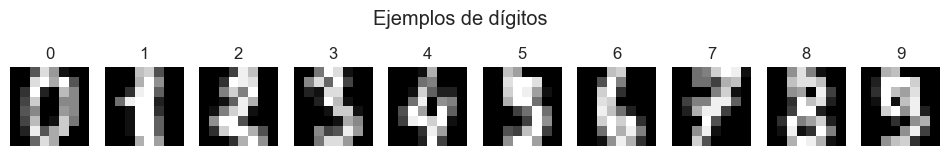

In [2]:
from sklearn.datasets import load_digits
digits = load_digits()
X, y = digits.data, digits.target
print(f"Shape de X: {X.shape}, Shape de y: {y.shape}")

fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for i, ax in enumerate(axes):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"{digits.target[i]}")
    ax.axis('off')
plt.suptitle('Ejemplos de dígitos')
plt.show()

## 4. Preprocesamiento de datos

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')

Train: (1437, 64), Test: (360, 64)


## 5. MLP con scikit-learn

Entrenaremos un perceptrón multicapa usando `MLPClassifier` de scikit-learn.

Accuracy: 0.9667 | Tiempo: 1.75s


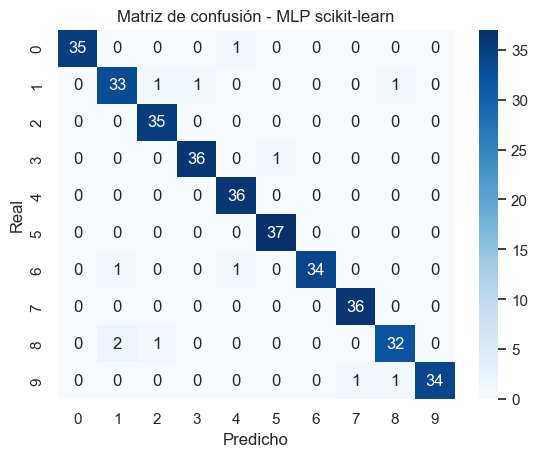

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      0.92      0.92        36
           2       0.95      1.00      0.97        35
           3       0.97      0.97      0.97        37
           4       0.95      1.00      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.94      0.97        36
           7       0.97      1.00      0.99        36
           8       0.94      0.91      0.93        35
           9       1.00      0.94      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [4]:
start = time.time()
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam',
                    max_iter=200, random_state=SEED)
mlp.fit(X_train_scaled, y_train)
sklearn_time = time.time() - start

y_pred = mlp.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f} | Tiempo: {sklearn_time:.2f}s")
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión - MLP scikit-learn')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()
print(classification_report(y_test, y_pred))

### Curva de pérdida (scikit-learn)

Visualizamos cómo evoluciona la pérdida durante el entrenamiento.

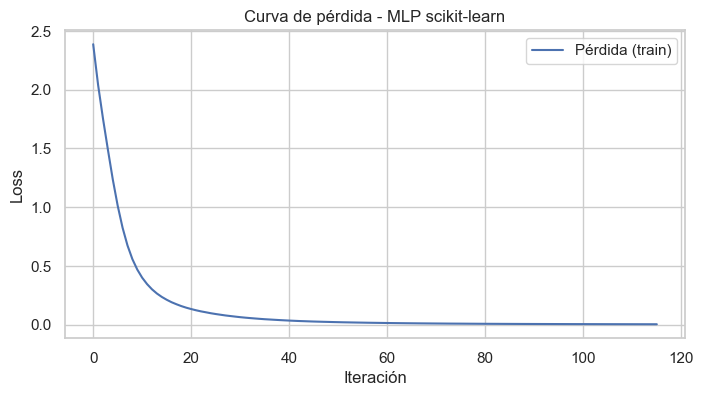

In [5]:
plt.figure(figsize=(8,4))
plt.plot(mlp.loss_curve_, label='Pérdida (train)')
plt.title('Curva de pérdida - MLP scikit-learn')
plt.xlabel('Iteración')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## 6. MLP con TensorFlow/Keras

Ahora construiremos y entrenaremos una red neuronal densa usando Keras, visualizando **tanto accuracy como loss**.

In [6]:
# Preparar datos para Keras
num_classes = len(np.unique(y))
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

# Definir modelo
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Entrenar con medición de tiempo
start = time.time()
history = model.fit(X_train_scaled, y_train_cat, epochs=30, batch_size=32,
                    validation_split=0.2, verbose=0)
keras_time = time.time() - start

# Evaluar
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"\nAccuracy (Keras): {test_acc:.4f} | Tiempo: {keras_time:.2f}s")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,570 (25.66 KB)

 Trainable params: 6,570 (25.66 KB)

 Non-trainable params: 0 (0.00 B)


Accuracy (Keras): 0.9694 | Tiempo: 10.07s


### Visualización de la arquitectura de la red MLP

Podemos mostrar un diagrama de la arquitectura de la red neuronal usando `plot_model` de Keras. Esto ayuda a entender la estructura de capas y conexiones.

In [7]:
# Visualizar la arquitectura del modelo MLP
from tensorflow.keras.utils import plot_model
from IPython.display import Image, display

# Asume que el modelo se llama 'model'
plot_model(model, show_shapes=True, show_layer_names=True, to_file='mlp_model.png', dpi=70)

import os
if os.path.exists('mlp_model.png'):
    display(Image(filename='mlp_model.png'))
else:
    print("No se pudo generar la imagen. Verifica que tienes instalados 'pydot' y 'graphviz'.")

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
No se pudo generar la imagen. Verifica que tienes instalados 'pydot' y 'graphviz'.


### Curvas de aprendizaje (accuracy y loss)

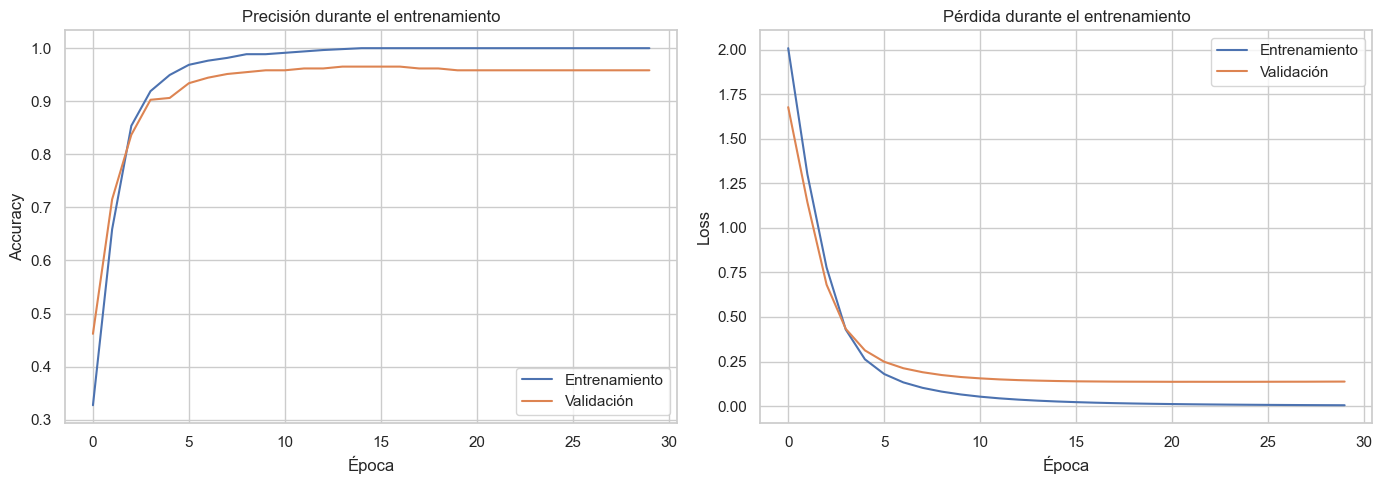

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Entrenamiento')
axes[0].plot(history.history['val_accuracy'], label='Validación')
axes[0].set_title('Precisión durante el entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Entrenamiento')
axes[1].plot(history.history['val_loss'], label='Validación')
axes[1].set_title('Pérdida durante el entrenamiento')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


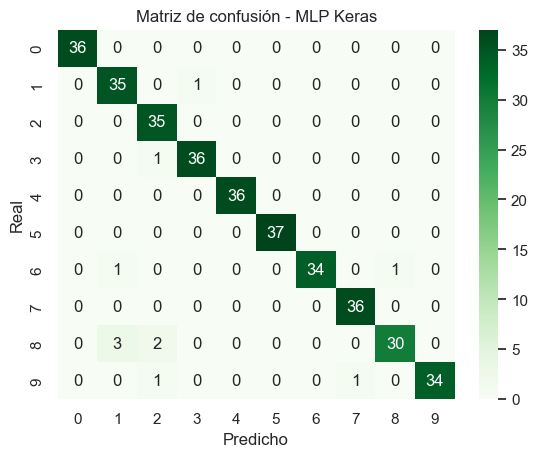

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.90      0.97      0.93        36
           2       0.90      1.00      0.95        35
           3       0.97      0.97      0.97        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      0.94      0.97        36
           7       0.97      1.00      0.99        36
           8       0.97      0.86      0.91        35
           9       1.00      0.94      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



In [9]:
# Predicciones y matriz de confusión
y_pred_keras = np.argmax(model.predict(X_test_scaled), axis=1)
cm_keras = confusion_matrix(y_test, y_pred_keras)
sns.heatmap(cm_keras, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de confusión - MLP Keras')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()
print(classification_report(y_test, y_pred_keras))

## 7. Ajuste de hiperparámetros

Exploraremos el impacto de los hiperparámetros clave: número de capas, neuronas, función de activación y regularización.

In [10]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'solver': ['adam']
}
gs = GridSearchCV(MLPClassifier(max_iter=200, random_state=SEED), param_grid, cv=3, n_jobs=-1)
gs.fit(X_train_scaled, y_train)
print("Mejores parámetros (scikit-learn):", gs.best_params_)
print("Mejor accuracy (CV):", f"{gs.best_score_:.4f}")

Mejores parámetros (scikit-learn): {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'solver': 'adam'}
Mejor accuracy (CV): 0.9736


### Recomendaciones prácticas para MLP

| Aspecto | Recomendación |
|---------|---------------|
| **Datos insuficientes** | Aumenta la cantidad de datos si es posible |
| **Sobreajuste** | Usa regularización: `alpha` (sklearn), `Dropout` (Keras) |
| **Arquitectura** | Ajusta capas y neuronas según la complejidad del problema |
| **Activación** | Usa `relu` por defecto; prueba `tanh` si hay problemas |
| **Monitoreo** | Visualiza curvas de loss y accuracy siempre |
| **Early Stopping** | Usa `EarlyStopping` en Keras para evitar sobreentrenamiento |
| **GPU** | Aprovecha TensorFlow/Keras para acelerar con GPU |

### Comparación de tiempos de entrenamiento

In [11]:
print(f'Tiempo scikit-learn: {sklearn_time:.2f}s')
print(f'Tiempo Keras:        {keras_time:.2f}s')
print(f'\n💡 Para datasets pequeños, scikit-learn puede ser más rápido.')
print(f'   Para datasets grandes y modelos complejos, Keras + GPU es más eficiente.')

Tiempo scikit-learn: 1.75s
Tiempo Keras:        10.07s

💡 Para datasets pequeños, scikit-learn puede ser más rápido.
   Para datasets grandes y modelos complejos, Keras + GPU es más eficiente.


## 8. Discusión y Conclusiones

- Vimos cómo implementar y comparar MLP con scikit-learn y Keras.
- Visualizamos tanto accuracy como loss durante el entrenamiento.
- La elección entre scikit-learn y Keras depende del tamaño del problema y la necesidad de GPU.
- El ajuste de hiperparámetros es esencial para un buen desempeño.
- En notebooks siguientes exploraremos arquitecturas más avanzadas: CNN, RNN, Transformers.

## 9. Ejercicios Propuestos

1. **Ejercicio 1:** Agrega una capa `Dropout(0.3)` entre las capas densas del modelo Keras. ¿Reduce el sobreajuste?

2. **Ejercicio 2:** Implementa `EarlyStopping` con `patience=5` y compara la época óptima vs el modelo sin early stopping.

3. **Ejercicio 3:** Cambia el dataset a MNIST completo (`keras.datasets.mnist`). ¿Cómo impacta el tamaño del dataset en el accuracy y tiempo?

4. **Ejercicio 4 (Avanzado):** Implementa un MLP con `BatchNormalization` entre capas. ¿Mejora la convergencia?

# Resolución de Ejercicios Propuestos

En esta sección, abordaremos técnicas críticas para entrenar redes neuronales eficientes y escalables:

1.  **Ejercicio 2: Prevención del Sobreajuste con EarlyStopping.** Configuraremos un monitor que detenga el entrenamiento automáticamente cuando nuestra red deje de aprender, ahorrando tiempo de cómputo.
2.  **Ejercicio 3: Escalabilidad con MNIST completo.** Pasaremos de un dataset de prueba ("juguete") al dataset MNIST original de Keras (60,000 imágenes de 28x28 píxeles) para observar el impacto masivo de los datos en el *accuracy* y el tiempo de ejecución.

## Ejercicio 2: Monitoreo con Early Stopping

Entrenar una red neuronal por demasiadas épocas (epochs) casi siempre conduce al *overfitting* (el modelo memoriza los datos de entrenamiento pero falla en datos nuevos).
Usaremos el *Callback* `EarlyStopping` de Keras para monitorear la pérdida de validación (`val_loss`). Si la pérdida no mejora (disminuye) durante 5 épocas consecutivas (`patience=5`), el entrenamiento se abortará y restauraremos los mejores pesos encontrados.

In [13]:
# 1. Definimos una red neuronal densa simple (MLP)
def crear_modelo():
    modelo = Sequential([
        # Asegúrate de que la dimensión de entrada (input_shape) coincida con tus datos actuales (ej. 64 si usas digits de sklearn)
        # Shape de X: (1797, 64), Shape de y: (1797,)
        Dense(1797, activation='relu', input_shape=(X_train.shape[1],)), 
        Dense(64, activation='relu'),
        # Suponiendo 10 clases (del 0 al 9)
        Dense(10, activation='softmax') 
    ])
    
    modelo.compile(optimizer='adam', 
                   loss='sparse_categorical_crossentropy', 
                   metrics=['accuracy'])
    return modelo

# 2. Creamos el Callback EarlyStopping
# 'restore_best_weights=True' asegura que nos quedemos con el mejor modelo, no con el modelo de la última época evaluada
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1 # Para que imprima un mensaje cuando se detenga
)

# 3. Entrenamos el modelo usando un número exagerado de épocas (ej. 100)
# ¡Veremos que se detiene mucho antes gracias al Early Stopping!
print("Iniciando entrenamiento con Early Stopping...")

modelo_es = crear_modelo()
historia_es = modelo_es.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stop], 
    verbose=0 # verbose=0 para no imprimir todas las épocas, EarlyStopping nos avisará
)

# 4. Resultados
epoca_optima = early_stop.stopped_epoch - 5 if early_stop.stopped_epoch > 0 else 100
print(f"\nEl entrenamiento se detuvo en la época: {early_stop.stopped_epoch}")
print(f"La época óptima (mejores pesos restaurados) fue la: {epoca_optima}")

# Evaluamos final
test_loss, test_acc = modelo_es.evaluate(X_test, y_test, verbose=0)
print(f"Accuracy final en Test: {test_acc:.4f}")

Iniciando entrenamiento con Early Stopping...
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 13.

El entrenamiento se detuvo en la época: 17
La época óptima (mejores pesos restaurados) fue la: 12
Accuracy final en Test: 0.9861


## Ejercicio 3: Impacto de la cantidad de datos (MNIST nativo de Keras)

Hasta ahora hemos trabajado con datasets pequeños de Scikit-Learn. Ahora usaremos el dataset **MNIST completo** de Keras que es más grande.
*   **Imágenes originales:** 60,000 imágenes para entrenamiento y 10,000 para evaluación.
*   **Resolución real:** 28x28 píxeles (comparado con los 8x8 que veníamos usando).

Aplanaremos (Flatten) las imágenes 2D (28x28) a vectores 1D (784 características) para poder introducirlas en nuestras capas Densas.

In [15]:
# 1. Carga masiva de datos reales
print("Descargando el dataset MNIST gigante de Keras...")
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

print(f"Forma original Train: {X_train_full.shape} (60 mil imágenes de 28x28)")

# 2. Preprocesamiento: Aplanado (Flatten) y Normalización (0-1)
# 28 * 28 = 784 píxeles (características)
X_train_flat = X_train_full.reshape(-1, 28*28) / 255.0
X_test_flat = X_test_full.reshape(-1, 28*28) / 255.0

# 3. Definición de un modelo más robusto para 784 entradas
modelo_mnist = Sequential([
    Dense(256, activation='relu', input_shape=(784,)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

modelo_mnist.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

# 4. Entrenamiento y medición del tiempo
print("\nIniciando entrenamiento del MNIST completo...")
inicio_tiempo = time.time()

# Agregamos también el EarlyStopping por si acaso
historia_mnist = modelo_mnist.fit(
    X_train_flat, y_train_full,
    epochs=20, # Reducimos epochs máximas porque cada una tarda más
    batch_size=128, # Procesamos 128 imágenes a la vez por eficiencia
    validation_split=0.2, # Apartamos un 20% del train para validación
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1 # Aquí si queremos ver la barra de progreso de épocas
)

fin_tiempo = time.time()

# 5. Evaluación Final
print(f"\nTiempo de entrenamiento total: {(fin_tiempo - inicio_tiempo):.2f} segundos")

test_loss_m, test_acc_m = modelo_mnist.evaluate(X_test_flat, y_test_full, verbose=0)
print(f"Accuracy astronómico en MNIST Test real: {test_acc_m:.4f}")

Descargando el dataset MNIST gigante de Keras...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 56s 5us/step
Forma original Train: (60000, 28, 28) (60 mil imágenes de 28x28)

Iniciando entrenamiento del MNIST completo...
Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9127 - loss: 0.3066 - val_accuracy: 0.9558 - val_loss: 0.1485
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9654 - loss: 0.1207 - val_accuracy: 0.9647 - val_loss: 0.1165
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.9774 - loss: 0.0771 - val_accuracy: 0.9687 - val_loss: 0.1034
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9840 - loss: 0.0546 - val_accuracy: 0.9732 - val_loss: 0.0930
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9884 - loss: 0.0408 - val_accuracy: 0.9742 - val_loss: 0.0902
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9921 - loss: 0.0298 - val_accuracy: 0.9769 - val_loss: 0.0842
Epoch 7/20
37

## Conclusión Final

Al finalizar esta sección práctica con Redes Neuronales Densas (MLP), podemos destacar dos grandes aprendizajes sobre el entrenamiento de modelos de Deep Learning:

### 1. La Eficiencia del Early Stopping (Ejercicio 2)
*   **Resultados:** Al configurar nuestro modelo con una paciencia de 5 épocas, el entrenamiento, originalmente programado para 100 iteraciones, **se detuvo abruptamente en la época 17**. El *callback* identificó inteligentemente que el modelo alcanzó su pico de rendimiento en la **época 12**, restaurando esos pesos y logrando un excelente accuracy en test del **98.61%**.
*   **Análisis:** Este resultado demuestra visualmente el concepto de *overfitting* (sobreajuste). Más allá de la época 12, la red comenzó a memorizar detalles innecesarios del set de entrenamiento, lo que habría degradado su capacidad de generalización. El *EarlyStopping* no solo salvó a nuestro modelo de empeorar, sino que nos **ahorró el tiempo computacional** de calcular 83 épocas inútiles.

### 2. El Impacto Masivo de los Datos (Ejercicio 3)
*   **Resultados:** Al cambiar al dataset MNIST completo (60,000 imágenes de 28x28), el tiempo de cómputo aumentó drásticamente a **42.71 segundos** (incluso deteniéndose en solo 9 épocas por *EarlyStopping*). Sin embargo, la red demostró un desempeño formidable, logrando un **97.82% de accuracy** sobre 10,000 imágenes completamente nuevas en el set de prueba.
*   **Análisis:** "Más datos vencen a modelos más complejos". Al proporcionarle a la red un volumen representativo de información (784 características por imagen), el modelo es capaz de extraer patrones de bordes, curvas y trazos universales para los dígitos manuscritos. La caída de la función de pérdida (`loss`) de manera tan acelerada en las primeras épocas confirma que la arquitectura densa es muy buena mapeando este tipo de abstracciones numéricas cuando tiene suficiente "combustible" (datos).

### Reflexión General
El Deep Learning moderno depende tanto de la **calidad/cantidad de los datos** como de las técnicas de **monitoreo**. Combinando arquitecturas profundas con *callbacks* inteligentes como *EarlyStopping*, podemos lograr sistemas estables y precisos de manera computacionalmente responsable.

## 10. Referencias y Recursos

- [scikit-learn MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)
- [TensorFlow/Keras Sequential](https://keras.io/guides/sequential_model/)
- [EarlyStopping Callback](https://keras.io/api/callbacks/early_stopping/)
- Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.*

---

📎 **Notebook anterior:** [03. Modelos Clásicos de ML](./03_modelos_clasicos_ml.ipynb)  
📎 **Notebook siguiente:** [05. Redes Convolucionales (CNN)](./05_redes_convolucionales_cnn.ipynb)